<a href="https://colab.research.google.com/github/LaraDondossola/Data-science/blob/main/aula_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

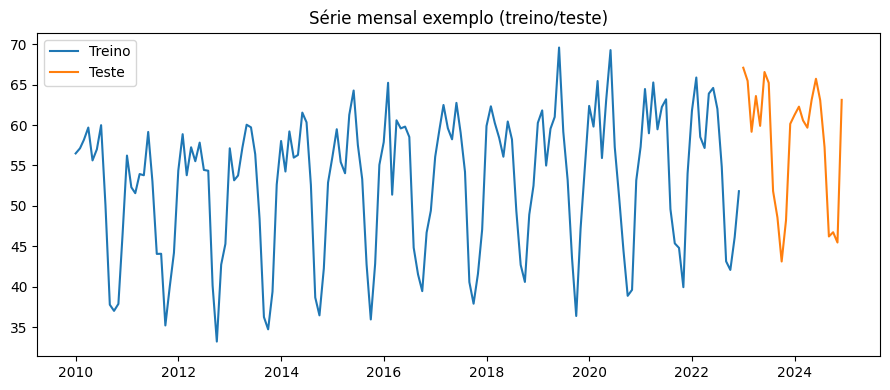

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1) Criar o dado e dividir entre treino e teste
rng = pd.date_range("2010-01-01", periods=180, freq="MS")  # 15 anos
np.random.seed(42)
trend = 0.5 * np.arange(len(rng)) / 12.0
seasonal_pattern = 10*np.sin(2*np.pi*np.arange(len(rng))/12) + 5*np.cos(2*np.pi*np.arange(len(rng))/6)
noise = np.random.normal(0, 3, size=len(rng))
y = 50 + trend + seasonal_pattern + noise
y = pd.Series(y, index=rng, name="valor")

# 2) Train / Test split (últimos 24 meses para teste)
h = 24
y_train, y_test = y.iloc[:-h], y.iloc[-h:]

plt.figure(figsize=(9,4))
plt.plot(y_train, label="Treino")
plt.plot(y_test, label="Teste")
plt.title("Série mensal exemplo (treino/teste)")
plt.legend()
plt.tight_layout(); plt.show()






# # 7) Busca de hiperparâmetros (grade pequena, bom para aula)
# def try_fit(order, seasonal_order):
#     try:
#         res = SARIMAX(y_train, order=order, seasonal_order=seasonal_order,
#                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
#         return (order, seasonal_order, res.aic, res)
#     except Exception:
#         return None

# candidates = []
# for p in [0,1,2]:
#     for q in [0,1,2]:
#         for P in [0,1]:
#             for Q in [0,1]:
#                 result = try_fit(order=(p,d,q), seasonal_order=(P,D,Q,s))
#                 if result is not None:
#                     candidates.append(result)

# candidates = sorted(candidates, key=lambda x: x[2])  # ordenar por AIC
# print("Top 5 por AIC:")
# for (order, seas, aic, _) in candidates[:5]:
#     print(f"  order={order}, seasonal={seas}, AIC={aic:.2f}")

# best_order, best_seasonal, best_aic, best_model = candidates[0]
# print(f"\nEscolhido: order={best_order}, seasonal={best_seasonal}, AIC={best_aic:.2f}")
# print(best_model.summary())

# # 8) Diagnóstico de resíduos
# resid = best_model.resid
# plt.figure(figsize=(9,3)); plt.plot(resid); plt.title("Resíduos do modelo"); plt.tight_layout(); plt.show()

# lb = acorr_ljungbox(resid, lags=[12], return_df=True)
# print("\nLjung-Box (lag 12):")
# print(lb)

# # 9) Previsão (h passos fora da amostra)
# fc = best_model.get_forecast(steps=h)
# fc_mean = fc.predicted_mean
# fc_ci = fc.conf_int()

# plt.figure(figsize=(10,4))
# plt.plot(y_train, label="Treino")
# plt.plot(y_test, label="Teste")
# plt.plot(fc_mean, label="Previsão")
# plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2, label="IC 95%")
# plt.title(f"SARIMA{best_order}x{best_seasonal} - Forecast {h} meses")
# plt.legend()
# plt.tight_layout(); plt.show()

# # 10) Métricas
# rmse = mean_squared_error(y_test, fc_mean, squared=False)
# mape = mean_absolute_percentage_error(y_test, fc_mean)
# print(f"RMSE: {rmse:.3f} | MAPE: {mape:.2%}")

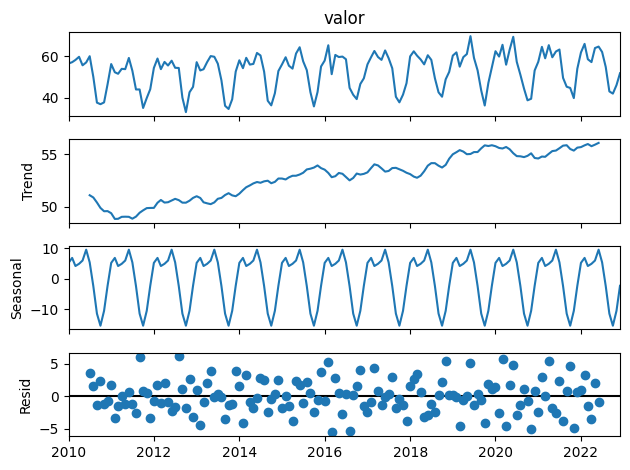

In [ ]:
# 3) Decomposição sazonal (para visual didático)
decomp = seasonal_decompose(y_train, model="additive", period=12)
decomp.plot(); plt.tight_layout(); plt.show()



In [ ]:
# Aplicando o fluxo para aplicar ARIMA
# Parte 1) Teste ADF no treino (nível)
adf_stat, pval, *_ = adfuller(y_train)
print(f"ADF (nível) p-valor: {pval:.4f}")

ADF (nível) p-valor: 0.8919


In [ ]:
# Parte 2) Diferenciar: escolha simples para aula
# Regra prática: se p-valor > 0.05, usar d=1; sazonalidade evidente -> D=1
d = 1 if pval > 0.05 else 0
D = 1  # temos sazonalidade explícita (mensal), então começamos com D=1
s = 12


ADF após diferenciação p-valor: 0.0000
Após as diferenças, a série apresenta indícios de estacionariedade.


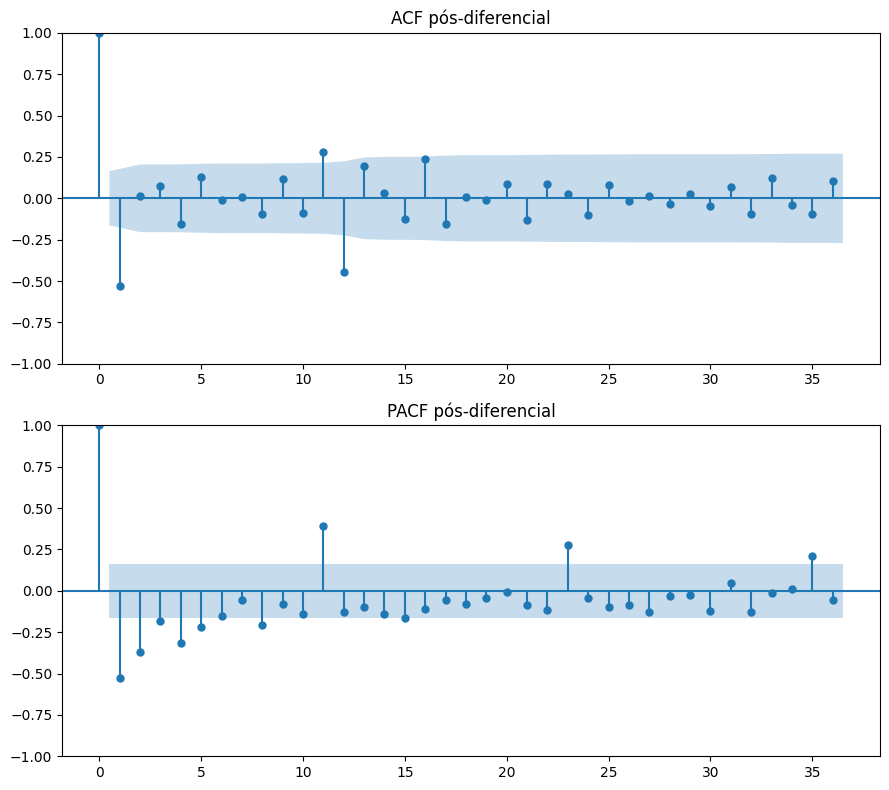

In [ ]:
# Parte 3 e 4) ACF/PACF após diferenças sugeridas (didático)
y_work = y_train.copy()
if d == 1:
    y_work = y_work.diff().dropna()
if D == 1:
    y_work = y_work.diff(s).dropna()
# Verificar novamente se a série ficou estacionária após as diferenças
adf_stat_diff, pval_diff, *_ = adfuller(y_work)
print(f"ADF após diferenciação p-valor: {pval_diff:.4f}")

if pval_diff <= 0.05:
    print("Após as diferenças, a série apresenta indícios de estacionariedade.")
else:
    print("Mesmo após as diferenças, a série ainda pode não estar estacionária.")


fig = plt.figure(figsize=(9,8))
ax1 = fig.add_subplot(2,1,1); plot_acf(y_work, lags=36, ax=ax1); ax1.set_title("ACF pós-diferencial")
ax2 = fig.add_subplot(2,1,2); plot_pacf(y_work, lags=36, ax=ax2, method="ywm"); ax2.set_title("PACF pós-diferencial")
plt.tight_layout(); plt.show()

In [ ]:
# 5)  Treinar o modelo e avaliar o erro.
# Busca de hiperparâmetros SARIMA
# A ideia é testar combinações pequenas para fins didáticos.
# p, d, q = parte não sazonal
# P, D, Q, s = parte sazonal

import warnings
import pandas as pd
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Como d e D já foram definidos antes, vamos buscar p, q, P e Q
p_values = range(0, 4)   # 0, 1, 2, 3
q_values = range(0, 4)   # 0, 1, 2, 3
P_values = range(0, 3)   # 0, 1, 2
Q_values = range(0, 3)   # 0, 1, 2

resultados = []

best_aic = float("inf")
best_model = None
best_order = None
best_seasonal = None

for p, q, P, Q in product(p_values, q_values, P_values, Q_values):
    order = (p, d, q)
    seasonal_order = (P, D, Q, s)

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        resultados.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })

        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_model = fitted_model
            best_order = order
            best_seasonal = seasonal_order

    except Exception:
        continue

resultados_df = pd.DataFrame(resultados).sort_values("AIC")

print("Top 10 modelos por AIC:")
print(resultados_df.head(10))

print("\nMelhor modelo encontrado:")
print(f"Order: {best_order}")
print(f"Seasonal order: {best_seasonal}")
print(f"AIC: {best_aic:.2f}")

In [ ]:
# 8) Diagnóstico de resíduos

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = best_model.resid.dropna()

# Gráfico dos resíduos ao longo do tempo
plt.figure(figsize=(9, 3))
plt.plot(resid)
plt.axhline(0, linestyle="--")
plt.title("Resíduos do modelo")
plt.tight_layout()
plt.show()

# ACF dos resíduos
plot_acf(resid, lags=24)
plt.title("ACF dos resíduos")
plt.tight_layout()
plt.show()

# Teste Ljung-Box
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)

print("\nLjung-Box:")
print(lb)

# Diagnóstico completo do modelo
best_model.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# 9) Previsão (h passos fora da amostra)
fc = best_model.get_forecast(steps=h)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

plt.figure(figsize=(10,4))
plt.plot(y_train, label="Treino")
plt.plot(y_test, label="Teste")
plt.plot(fc_mean, label="Previsão")
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2, label="IC 95%")
plt.title(f"SARIMA{best_order}x{best_seasonal} - Forecast {h} meses")
plt.legend()
plt.tight_layout(); plt.show()

# 10) Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, fc_mean)
rmse = np.sqrt(mean_squared_error(y_test, fc_mean))
mape = mean_absolute_percentage_error(y_test, fc_mean)

print(f"MAE: (erro médio absoluto) {mae:.3f}")
print(f"RMSE: (penaliza erros maiores) {rmse:.3f}")
print(f"MAPE: (erro percentual médio) {mape:.2%}")